# Sentiment Analysis on E-Commerce Reviews Using BERT

Environment Setup
-----------------
Configure Kaggle environment for PyTorch and Hugging Face compatibility.

Key Actions:
1. Uninstall TensorFlow to prevent backend conflicts
2. Install PyTorch, Transformers, and supporting libraries
3. Upgrade Protobuf for compatibility

⚠️ IMPORTANT: After running this cell, RESTART THE SESSION/KERNEL

In [1]:

# Uninstall TensorFlow to prevent backend conflicts
!pip uninstall -y tensorflow

# Install Deep Learning libraries
!pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -U accelerate transformers datasets scipy

# Install text preprocessing helpers
!pip install emoji beautifulsoup4 scikit-learn matplotlib seaborn

# Upgrade Protobuf
!pip install --upgrade protobuf

print("Environment Setup Complete.")
print("⚠️ ACTION REQUIRED: Please RESTART SESSION now.")

Looking in indexes: https://download.pytorch.org/whl/cu118
Environment Setup Complete.
⚠️ ACTION REQUIRED: Please RESTART SESSION now.


**Import all necessary libraries and download NLTK data**

In [2]:
import pandas as pd
import numpy as np
import re
import os
import torch
import scipy.sparse
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import google.protobuf

# Download NLTK assets
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    
try:
    nltk.data.find('corpus/stopwords')
except LookupError:
    nltk.download('stopwords')

print("✓ All libraries imported successfully")

# Create custom stopword list (preserving negations)
all_stopwords = set(stopwords.words('english'))
negative_words = {
    'not', 'no', 'nor', 'never', 'don', "don't", 'ain', 'aren', "aren't", 
    'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 
    'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 
    'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 
    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}
final_stop_words = all_stopwords - negative_words

print(f"\nStopword Configuration:")
print(f"  Total stopwords: {len(all_stopwords)}")
print(f"  Negative words preserved: {len(negative_words)}")
print(f"  Final stopwords to remove: {len(final_stop_words)}")

✓ All libraries imported successfully

Stopword Configuration:
  Total stopwords: 198
  Negative words preserved: 41
  Final stopwords to remove: 158


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Pre-Processing

**Load dataset and perform initial exploration**

In [3]:
file_path = '../input/womens-ecommerce-clothing-reviews/Womens Clothing E-Commerce Reviews.csv'

try:
    df = pd.read_csv(file_path)
    print(f"✓ Successfully loaded data. Shape: {df.shape}")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nFirst few rows:")
    print(df.head())
except FileNotFoundError:
    print(f"⚠️ File not found.")

print(f"\nData Info:")
print(df.info())

# 3. Perform 80/10/10 Split
# First, split into 80% Train and 20% Temporary
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

# Next, split the 20% Temporary into 50% Val and 50% Test (which is 10% and 10% of total)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# 4. Convert to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

print(f"Total Data: {len(df)}")
print(f"Training Set (80%):   {len(train_df)}")
print(f"Validation Set (10%): {len(val_df)}")
print(f"Testing Set (10%):    {len(test_df)}")

✓ Successfully loaded data. Shape: (23486, 11)

Columns: ['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

First few rows:
   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   
3           3         1049   50         My favorite buy!   
4           4          847   47         Flattering shirt   

                                         Review Text  Rating  Recommended IND  \
0  Absolutely wonderful - silky and sexy and comf...       4                1   
1  Love this dress!  it's sooo pretty.  i happene...       5                1   
2  I had such high hopes for this dress and reall...       3                0   
3  I love, love, love this jumpsuit. it's fun, fl...       5              

**Perform DataFrame-level cleaning:**
1. Select relevant columns
2. Remove null values
3. Remove duplicates

In [4]:
print("\n" + "="*60)
print("DATAFRAME-LEVEL CLEANING")
print("="*60)

# Keep only relevant columns
print(f"\nOriginal shape: {df.shape}")
df_clean = df[['Review Text', 'Rating']].copy()

# Drop rows with missing values
df_clean = df_clean.dropna().reset_index(drop=True)
print(f"After dropping nulls: {df_clean.shape}")

# Remove duplicates
initial_count = df_clean.shape[0]
df_clean = df_clean.drop_duplicates(subset=['Review Text'])
print(f"After dropping duplicates: {df_clean.shape}")
print(f"  Removed {initial_count - df_clean.shape[0]} duplicate rows")


DATAFRAME-LEVEL CLEANING

Original shape: (23486, 11)
After dropping nulls: (22641, 2)
After dropping duplicates: (22634, 2)
  Removed 7 duplicate rows


**Map 1-5 star ratings to sentiment labels:**
- Ratings 4-5: Positive
- Rating 3: Neutral
- Ratings 1-2: Negative

In [5]:
def map_rating_to_sentiment(rating):
    """Convert 1-5 star rating to sentiment label"""
    rating = int(rating)
    if rating in [4, 5]:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    elif rating in [1, 2]:
        return 'Negative'
    else:
        return 'Unknown'

df_clean['sentiment'] = df_clean['Rating'].apply(map_rating_to_sentiment)

print("\n✓ Sentiment mapping complete")
print("\nSentiment Distribution:")
print(df_clean['sentiment'].value_counts())
print("\nPercentage Distribution:")
print(df_clean['sentiment'].value_counts(normalize=True) * 100)


✓ Sentiment mapping complete

Sentiment Distribution:
sentiment
Positive    17442
Neutral      2823
Negative     2369
Name: count, dtype: int64

Percentage Distribution:
sentiment
Positive    77.061059
Neutral     12.472387
Negative    10.466555
Name: proportion, dtype: float64


**Apply comprehensive text cleaning while preserving sentiment indicators**

  Applies text cleaning for sentiment analysis:
1. Remove HTML tags
2. Convert emojis to text
3. Lowercase normalization   
4. Remove hyphens
5. Remove special characters
6. Tokenization
7. Remove stopwords (keeping negations)
8. Clean whitespace

In [6]:
def clean_review_text_hybrid(text):
    
    # Remove HTML tags
    text = BeautifulSoup(str(text), "html.parser").get_text()
    
    # Convert emojis to text description
    text = emoji.demojize(text, delimiters=(" :", ": "))
    
    # Lowercase
    text = text.lower()
    
    # Replace hyphens with spaces
    text = re.sub(r'-', ' ', text)
    
    # Remove special characters (keep letters, numbers, basic punctuation)
    text = re.sub(r'[^a-z0-9\s.,!?]', '', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords (preserving negations)
    cleaned_tokens = [word for word in tokens if word.isalpha() and word not in final_stop_words]
    
    # Join tokens
    text = ' '.join(cleaned_tokens)
    
    # Final whitespace cleanup
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("\n" + "="*60)
print("TEXT-LEVEL CLEANING")
print("="*60)

df_clean['cleaned_text'] = df_clean['Review Text'].apply(clean_review_text_hybrid)

print("\n✓ Text cleaning complete")
print("\nSample Results:")
for idx in range(min(3, len(df_clean))):
    print(f"\n--- Sample {idx+1} ---")
    print(f"Original: {df_clean['Review Text'].iloc[idx][:100]}...")
    print(f"Rating: {df_clean['Rating'].iloc[idx]} → Sentiment: {df_clean['sentiment'].iloc[idx]}")
    print(f"Cleaned: {df_clean['cleaned_text'].iloc[idx]}")

# Remove empty cleaned texts
df_clean = df_clean[df_clean['cleaned_text'].str.len() > 0].reset_index(drop=True)
print(f"\nFinal shape after removing empty texts: {df_clean.shape}")


TEXT-LEVEL CLEANING

✓ Text cleaning complete

Sample Results:

--- Sample 1 ---
Original: Absolutely wonderful - silky and sexy and comfortable...
Rating: 4 → Sentiment: Positive
Cleaned: absolutely wonderful silky sexy comfortable

--- Sample 2 ---
Original: Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never...
Rating: 5 → Sentiment: Positive
Cleaned: love dress sooo pretty happened find store im glad bc never would ordered online bc petite bought petite love length hits little knee would definitely true midi someone truly petite

--- Sample 3 ---
Original: I had such high hopes for this dress and really wanted it to work for me. i initially ordered the pe...
Rating: 3 → Sentiment: Neutral
Cleaned: high hopes dress really wanted work initially ordered petite small usual size found outrageously small small fact could not zip reordered petite medium overall top half comfortable fit nicely bottom half tight layer several somewhat cheap 

**Save cleaned data for subsequent steps**

In [7]:
output_file = 'cleaned_reviews_for_annotation.csv'
final_df = df_clean[['cleaned_text', 'sentiment', 'Rating']]
final_df.to_csv(output_file, index=False)

print(f"\n✓ Successfully saved cleaned data to '{output_file}'")


✓ Successfully saved cleaned data to 'cleaned_reviews_for_annotation.csv'


# TEXT REPRESENTATION - BAG OF WORDS (BoW)

## TEXT REPRESENTATION TECHNIQUES


Traditional Approach: Bag of Words & TF-IDF

Bag of Words (BoW):
- Represents text as fixed-length vector of word counts
- Ignores grammar and word order
- Example: vocabulary {"dress", "fabric", "bad"} → "bad dress" = [1, 0, 1]

TF-IDF (Term Frequency - Inverse Document Frequency):
- Weighs words based on importance
- Reduces weight of common words, increases weight of rare descriptive words
- Formula: TF-IDF(t,d) = TF(t,d) × IDF(t)
  where IDF(t) = log(N / df(t))

In [8]:
print("\n" + "="*60)
print("TEXT REPRESENTATION: BAG OF WORDS")
print("="*60)

# Load cleaned data
df = pd.read_csv('/kaggle/working/cleaned_reviews_for_annotation.csv')
df = df.dropna(subset=['cleaned_text'])
print(f"\n✓ Data loaded. Shape: {df.shape}")

# Create Bag of Words representation
vectorizer_bow = CountVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 1)  # Unigrams only
)

bow_matrix = vectorizer_bow.fit_transform(df['cleaned_text'])

print(f"\n✓ Bag of Words vectorization complete")
print(f"  Matrix Shape: {bow_matrix.shape}")
print(f"  Vocabulary Size: {len(vectorizer_bow.get_feature_names_out())}")
print(f"  Sparsity: {(1.0 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])) * 100:.2f}%")

# View sample representation
feature_names = vectorizer_bow.get_feature_names_out()
first_vector = bow_matrix[0]

print(f"\n--- Sample BoW Representation ---")
print(f"Review: {df['cleaned_text'].iloc[0]}")
print(f"Non-zero word counts:")
for col_index in first_vector.indices[:10]:  # Show first 10
    print(f"  '{feature_names[col_index]}': {first_vector[0, col_index]}")

# Save BoW matrix
scipy.sparse.save_npz('bow_vectors.npz', bow_matrix)
print(f"\n✓ Saved BoW vectors to 'bow_vectors.npz'")


TEXT REPRESENTATION: BAG OF WORDS

✓ Data loaded. Shape: (22634, 3)

✓ Bag of Words vectorization complete
  Matrix Shape: (22634, 5000)
  Vocabulary Size: 5000
  Sparsity: 99.55%

--- Sample BoW Representation ---
Review: absolutely wonderful silky sexy comfortable
Non-zero word counts:
  'absolutely': 1
  'wonderful': 1
  'silky': 1
  'sexy': 1
  'comfortable': 1

✓ Saved BoW vectors to 'bow_vectors.npz'


# TEXT REPRESENTATION - TF-IDF

**TF-IDF Vectorization**

In [9]:
print("\n" + "="*60)
print("TEXT REPRESENTATION: TF-IDF")
print("="*60)

# Create TF-IDF representation
vectorizer_tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)  # Unigrams and bigrams
)

tfidf_matrix = vectorizer_tfidf.fit_transform(df['cleaned_text'])

print(f"\n✓ TF-IDF vectorization complete")
print(f"  Matrix Shape: {tfidf_matrix.shape}")
print(f"  Vocabulary Size: {len(vectorizer_tfidf.get_feature_names_out())}")

# View sample TF-IDF scores
feature_names_tfidf = vectorizer_tfidf.get_feature_names_out()
first_vector_tfidf = tfidf_matrix[0]

print(f"\n--- Sample TF-IDF Representation ---")
print(f"Review: {df['cleaned_text'].iloc[0]}")

# Get top TF-IDF scores
tfidf_scores = [(feature_names_tfidf[i], first_vector_tfidf[0, i]) 
                for i in first_vector_tfidf.indices]
tfidf_scores.sort(key=lambda x: x[1], reverse=True)

print(f"Top 10 TF-IDF scores:")
for word, score in tfidf_scores[:10]:
    print(f"  '{word}': {score:.4f}")

# Save TF-IDF matrix
scipy.sparse.save_npz('tfidf_vectors.npz', tfidf_matrix)
print(f"\n✓ Saved TF-IDF vectors to 'tfidf_vectors.npz'")


TEXT REPRESENTATION: TF-IDF

✓ TF-IDF vectorization complete
  Matrix Shape: (22634, 5000)
  Vocabulary Size: 5000

--- Sample TF-IDF Representation ---
Review: absolutely wonderful silky sexy comfortable
Top 10 TF-IDF scores:
  'silky': 0.5491
  'sexy': 0.5038
  'wonderful': 0.4739
  'absolutely': 0.3845
  'comfortable': 0.2688

✓ Saved TF-IDF vectors to 'tfidf_vectors.npz'


# EMBEDDINGS - BERT TOKENIZATION

## MODERN APPROACH: CONTEXTUAL EMBEDDINGS (BERT)


Unlike TF-IDF (static vectors), BERT generates contextual embeddings:
- Same word gets different vectors based on context
- Example: "bank" in "river bank" vs "bank account"
- Uses Transformer architecture with self-attention
- Captures polysemy and complex syntactic structures

In [15]:
# ==========================================
# CONTEXTUAL EMBEDDINGS: BERT TOKENIZATION
# ==========================================

print("Starting BERT Tokenization...")

# 1. Load data
file_path = 'cleaned_reviews_for_annotation.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    df = df.dropna(subset=['cleaned_text', 'sentiment'])
    sentences = df['cleaned_text'].values.tolist()
    labels = df['sentiment'].values
    print(f"✓ Data loaded. Shape: {df.shape}")
else:
    raise FileNotFoundError("Error: Cleaned CSV not found. Run Preprocessing first.")

# 2. Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print(f"✓ BERT tokenizer loaded")

# 3. Tokenize the text (Create Embeddings Inputs)
encoded_data = tokenizer.batch_encode_plus(
    sentences,
    add_special_tokens=True,      # Add [CLS] and [SEP]
    return_attention_mask=True,   # Generate attention masks
    padding='max_length',         # Pad to max_length
    truncation=True,              # Truncate if too long
    max_length=128,
    return_tensors='pt'           # Return PyTorch tensors
)

input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']

# 4. Map sentiment labels to numbers
label_map = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
numeric_labels = torch.tensor([label_map.get(l, 1) for l in labels])

# 5. Save prepared data
dataset = {
    'input_ids': input_ids,
    'attention_masks': attention_masks,
    'labels': numeric_labels
}

torch.save(dataset, 'bert_prepared_data.pt')
print(f"✓ Saved prepared data to 'bert_prepared_data.pt'")


# ==========================================
# VERIFICATION & SANITY CHECK
# ==========================================
print("\n" + "="*40)
print("EMBEDDING VERIFICATION LOGS")
print("="*40)

# CHECK 1: Tensor Shapes
print(f"Tensor Shapes (Must be [Rows, 128]):")
print(f" > Input IDs:       {input_ids.shape}")
print(f" > Attention Masks: {attention_masks.shape}")
print(f" > Labels:          {numeric_labels.shape}")

# CHECK 2: Visual Inspection (Text vs Numbers)
# We look at the first review to see how BERT converted it.
idx = 0
print(f"\nSample Inspection (Row {idx}):")
print(f"-------------------------------")
print(f"Original Text:   {sentences[idx]}")
print(f"Sentiment Label: {labels[idx]} -> {numeric_labels[idx]}")

print(f"\nBERT Tokens (Decoded):")
# We decode the ID back to text to see special tokens [CLS], [SEP] and [PAD]
decoded_text = tokenizer.decode(input_ids[idx])
print(decoded_text)

print(f"\nActual Embedding Input (First 20 IDs):")
print(input_ids[idx][:20])

# CHECK 3: Attention Mask Check
# The mask should be 1 for words and 0 for [PAD]
print(f"\nAttention Mask (First 20):")
print(attention_masks[idx][:20])

print("\n✓ Verification Complete: Embeddings are ready for training.")

Starting BERT Tokenization...
✓ Data loaded. Shape: (22634, 3)
✓ BERT tokenizer loaded
✓ Saved prepared data to 'bert_prepared_data.pt'

EMBEDDING VERIFICATION LOGS
Tensor Shapes (Must be [Rows, 128]):
 > Input IDs:       torch.Size([22634, 128])
 > Attention Masks: torch.Size([22634, 128])
 > Labels:          torch.Size([22634])

Sample Inspection (Row 0):
-------------------------------
Original Text:   absolutely wonderful silky sexy comfortable
Sentiment Label: Positive -> 2

BERT Tokens (Decoded):
[CLS] absolutely wonderful silky sexy comfortable [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD

# MODEL ARCHITECTURE OVERVIEW

## MODEL ARCHITECTURE: BERT FOR SEQUENCE CLASSIFICATION


BERT (Bidirectional Encoder Representations from Transformers)
--------------------------------------------------------------
- Architecture: Transformer Encoder stack (12 layers for base, 24 for large)
- Key Innovation: Self-Attention Mechanism
- Bidirectional: Analyzes context from both directions simultaneously

Self-Attention Mechanism:
-------------------------
For each token, compute attention weights with all other tokens:

Attention(Q,K,V) = softmax(QK^T / √d_k) V

where:
- Q (Query), K (Key), V (Value) are learned projections
- d_k is the dimension of key vectors (prevents vanishing gradients)

Task: Sentiment Classification (Sequence Classification)
--------------------------------------------------------
Objective: Classify sentiment (Positive, Negative, Neutral) of entire review

Model Structure:
1. Input Layer: Token embeddings + Position embeddings + Segment embeddings
2. BERT Encoder: 12 Transformer layers with self-attention
3. [CLS] Token: Aggregate sentence representation
4. Classification Head: 
   - Dropout(0.1)
   - Linear(768 → num_classes)
   - Softmax

Output: P(y|x) = softmax(W · h_[CLS] + b)

where:
- h_[CLS] is the final hidden state of [CLS] token
- W is the weight matrix
- b is the bias term

In [16]:
print("\n" + "="*60)
print("MODEL ARCHITECTURE")
print("="*60)
print("\nBERT-base-uncased Configuration:")
print("  - Layers: 12")
print("  - Hidden Size: 768")
print("  - Attention Heads: 12")
print("  - Parameters: ~110M")
print("  - Task: Sequence Classification (3 classes)")


MODEL ARCHITECTURE

BERT-base-uncased Configuration:
  - Layers: 12
  - Hidden Size: 768
  - Attention Heads: 12
  - Parameters: ~110M
  - Task: Sequence Classification (3 classes)


# MODEL TRAINING - DATA PREPARATION

**Prepare data for training**

In [17]:
print("\n" + "="*60)
print("MODEL TRAINING: DATA PREPARATION")
print("="*60)

# Load cleaned data
df = pd.read_csv('/kaggle/working/cleaned_reviews_for_annotation.csv')
df = df.dropna(subset=['cleaned_text', 'sentiment'])

# Map sentiment labels to integers
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['label'] = df['sentiment'].map(label_map)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(f"\n✓ Data loaded and labels mapped")
print(f"  Total samples: {len(df)}")
print(f"\nLabel Distribution:")
print(df['label'].value_counts().sort_index())

# Train-test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

print(f"\n✓ Data split complete")
print(f"  Training samples: {len(train_df)}")
print(f"  Testing samples: {len(test_df)}")

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df[['cleaned_text', 'label']])
test_dataset = Dataset.from_pandas(test_df[['cleaned_text', 'label']])

# Tokenization function
def tokenize_function(examples):
    return tokenizer(examples["cleaned_text"], 
                    padding="max_length", 
                    truncation=True, 
                    max_length=128)

# Apply tokenization
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

print(f"\n✓ Tokenization complete")


MODEL TRAINING: DATA PREPARATION

✓ Data loaded and labels mapped
  Total samples: 22634

Label Distribution:
label
0     2369
1     2823
2    17442
Name: count, dtype: int64

✓ Data split complete
  Training samples: 18107
  Testing samples: 4527


Map:   0%|          | 0/18107 [00:00<?, ? examples/s]

Map:   0%|          | 0/4527 [00:00<?, ? examples/s]


✓ Tokenization complete


# MODEL INITIALIZATION

**Initialize BERT model and define evaluation metrics**

In [18]:
print("\n" + "="*60)
print("MODEL INITIALIZATION")
print("="*60)

# Initialize model
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3,  # Negative, Neutral, Positive
    problem_type="single_label_classification"
)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"\n✓ Model loaded")
print(f"  Device: {device}")
print(f"  Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Define evaluation metrics
def compute_metrics(pred):
    """Calculate accuracy and F1 score"""
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {
        'accuracy': acc,
        'f1': f1
    }

print(f"\n✓ Metrics defined: Accuracy, Weighted F1-Score")


MODEL INITIALIZATION


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



✓ Model loaded
  Device: cuda
  Number of parameters: 109,484,547

✓ Metrics defined: Accuracy, Weighted F1-Score


# MODEL TRAINING

**Configure training parameters and train the model**


MODEL TRAINING

Training Configuration:
  Epochs: 10
  Batch Size: 16
  Learning Rate: 5e-05
  Warmup Steps: 500

STARTING TRAINING...



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.180100,0.583970,0.831677,0.826535
2,0.159300,0.681036,0.822620,0.824439
3,0.135600,1.025949,0.804948,0.821986
4,0.161100,0.880514,0.823724,0.821032
5,0.079300,1.031704,0.830793,0.817054
6,0.054800,1.139119,0.824166,0.827119
7,0.032400,1.295531,0.822620,0.825703
8,0.018900,1.480792,0.820190,0.827973
9,0.005800,1.478203,0.824608,0.827282
10,0.012600,1.523542,0.821074,0.825524



✓ TRAINING COMPLETE

Generating Learning Curves...


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

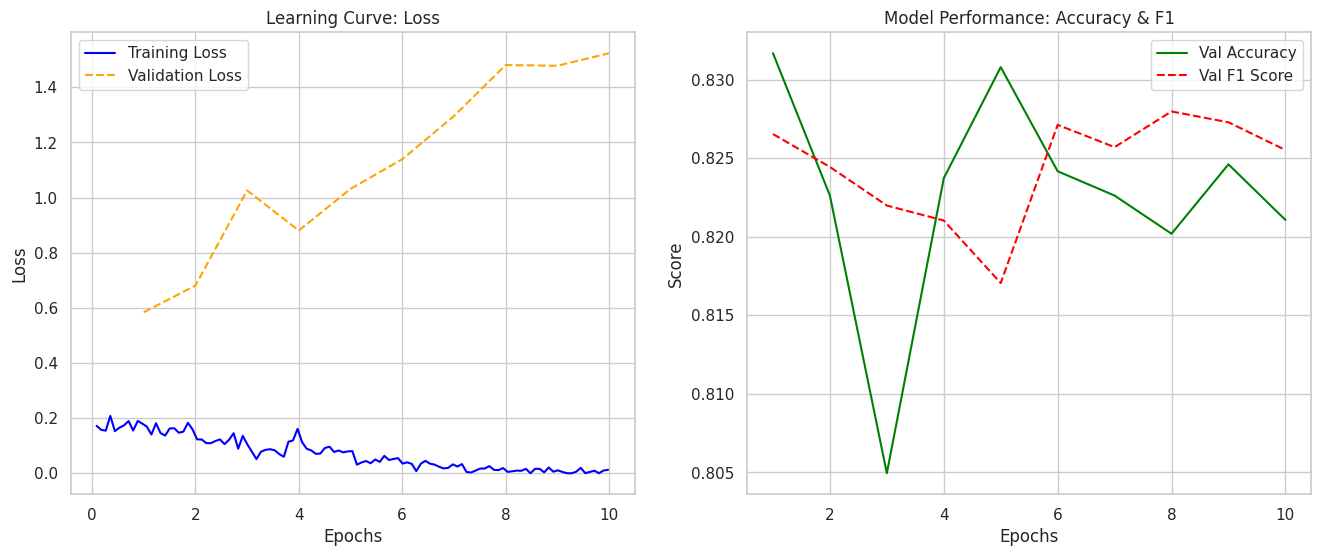

In [20]:
print("\n" + "="*60)
print("MODEL TRAINING")
print("="*60)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,              # Number of training epochs
    per_device_train_batch_size=16,  # Batch size for training
    per_device_eval_batch_size=16,   # Batch size for evaluation
    warmup_steps=500,                # Learning rate warmup
    weight_decay=0.01,               # Weight decay for regularization
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",           # Evaluate after each epoch
    save_strategy="epoch",           # Save model after each epoch
    load_best_model_at_end=True,     # Load best model at end
    metric_for_best_model='f1',      # Use F1 for model selection
    report_to="none"
)

print(f"\nTraining Configuration:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch Size: {training_args.per_device_train_batch_size}")
print(f"  Learning Rate: {training_args.learning_rate}")
print(f"  Warmup Steps: {training_args.warmup_steps}")

# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

# Start training
print(f"\n{'='*60}")
print("STARTING TRAINING...")
print(f"{'='*60}\n")

trainer.train()

print(f"\n{'='*60}")
print("✓ TRAINING COMPLETE")
print(f"{'='*60}")

print("\nGenerating Learning Curves...")

# A. Extract logs from trainer history
history = trainer.state.log_history

# Separate Training Loss and Validation Metrics
train_log = []
val_log = []

for entry in history:
    if 'loss' in entry:
        train_log.append(entry)
    elif 'eval_loss' in entry:
        val_log.append(entry)

# Convert to DataFrames
df_train = pd.DataFrame(train_log)
df_val = pd.DataFrame(val_log)

# B. Plotting
sns.set(style='whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Loss Curves (Training vs Validation)
# This graph tells you if you are Overfitting
if not df_train.empty and not df_val.empty:
    sns.lineplot(x='epoch', y='loss', data=df_train, label='Training Loss', ax=ax[0], color='blue')
    sns.lineplot(x='epoch', y='eval_loss', data=df_val, label='Validation Loss', ax=ax[0], color='orange', linestyle='--')
    ax[0].set_title('Learning Curve: Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
else:
    print("Not enough data to plot Loss Curve.")

# Graph 2: Accuracy & F1 Score (Validation Only)
# Note: HF Trainer usually doesn't calculate Training Accuracy per step to save speed.
if not df_val.empty:
    sns.lineplot(x='epoch', y='eval_accuracy', data=df_val, label='Val Accuracy', ax=ax[1], color='green')
    sns.lineplot(x='epoch', y='eval_f1', data=df_val, label='Val F1 Score', ax=ax[1], color='red', linestyle='--')
    ax[1].set_title('Model Performance: Accuracy & F1')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Score')
    ax[1].legend()

plt.show()

# MODEL EVALUATION

**Evaluate the trained model on test set**


MODEL EVALUATION



✓ Evaluation Results:
  eval_loss: 1.4808
  eval_accuracy: 0.8202
  eval_f1: 0.8280
  eval_runtime: 16.1688
  eval_samples_per_second: 279.9840
  eval_steps_per_second: 17.5030
  epoch: 10.0000

CLASSIFICATION REPORT

              precision    recall  f1-score   support

    Negative       0.64      0.53      0.58       474
     Neutral       0.39      0.53      0.45       565
    Positive       0.94      0.91      0.92      3488

    accuracy                           0.82      4527
   macro avg       0.66      0.65      0.65      4527
weighted avg       0.84      0.82      0.83      4527


Confusion Matrix:
[[ 250  185   39]
 [ 106  298  161]
 [  32  291 3165]]

✓ Saved confusion matrix to 'confusion_matrix.png'


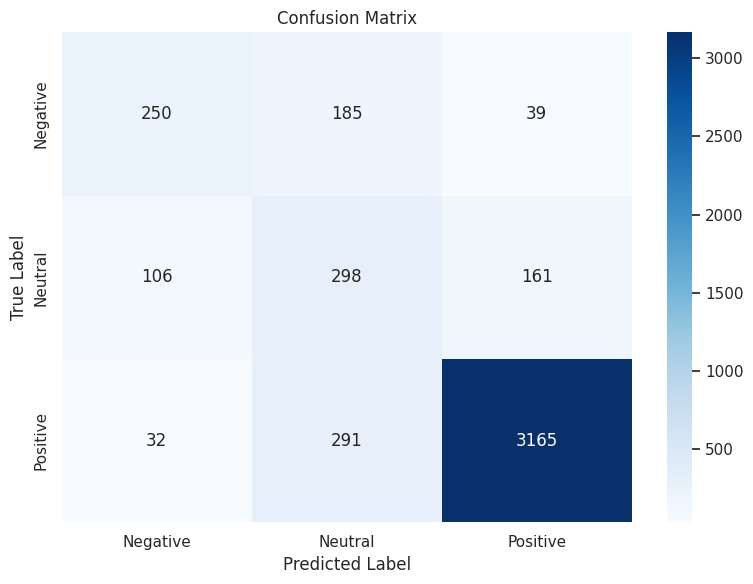

In [21]:
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Evaluate on test set
eval_results = trainer.evaluate()

print(f"\n✓ Evaluation Results:")
for key, value in eval_results.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# Get predictions
predictions = trainer.predict(tokenized_test)
preds = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

# Detailed classification report
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT")
print(f"{'='*60}\n")

target_names = ['Negative', 'Neutral', 'Positive']
print(classification_report(true_labels, preds, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(true_labels, preds)
print(f"\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved confusion matrix to 'confusion_matrix.png'")

# SAVE MODEL

**Save the trained model and tokenizer**

In [23]:
print("\n" + "="*60)
print("SAVING MODEL")
print("="*60)

model_path = "./final_sentiment_bert_model"
model.save_pretrained(model_path)
tokenizer.save_pretrained(model_path)

print(f"\n✓ Model saved to '{model_path}'")
print(f"\nModel files:")
print(f"  - config.json")
print(f"  - pytorch_model.bin")
print(f"  - tokenizer files")


SAVING MODEL

✓ Model saved to './final_sentiment_bert_model'

Model files:
  - config.json
  - pytorch_model.bin
  - tokenizer files


# INFERENCE

In [25]:
!pip install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.8/444.8 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.5 MB/s eta 0:00:00
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.5
    Uninstalling pydantic_core-2.41.5:
      Successfully uninstalled pydantic_core-2.41.5
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.4
    Uninstalling pydantic-2.12.4:
      Successfully uninstalled pydantic-2.12.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.17.0 requires scipy<1.16,>=1.4.1, but you have scipy 1.16.3 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [26]:
import gradio as gr
import torch
import torch.nn.functional as F
from transformers import BertTokenizer, BertForSequenceClassification
import os

# --- 1. Load the Trained Model ---
model_path = "./final_sentiment_bert_model"

if not os.path.exists(model_path):
    raise FileNotFoundError("Error: Saved model not found. Please run the Training Step first.")

print("Loading model for Gradio...")
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# --- 2. Define the Prediction Function ---
def predict_sentiment(text):
    # Tokenize
    inputs = tokenizer(
        text, 
        padding="max_length", 
        truncation=True, 
        max_length=128, 
        return_tensors="pt"
    )
    
    # Move to GPU
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Predict
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = F.softmax(logits, dim=1) # Convert logits to probabilities
    
    # Get probabilities as a dictionary for Gradio
    # Class mapping: 0: Negative, 1: Neutral, 2: Positive
    scores = probs.cpu().numpy()[0]
    result_dict = {
        "Negative 😡": float(scores[0]),
        "Neutral 😐": float(scores[1]),
        "Positive 😊": float(scores[2])
    }
    
    return result_dict

# --- 3. Build the Interface ---
app = gr.Interface(
    fn=predict_sentiment,
    
    # Inputs
    inputs=gr.Textbox(
        lines=3, 
        placeholder="Type a review here... (e.g., 'The dress is pretty but the fabric is cheap')",
        label="Customer Review"
    ),
    
    # Outputs
    outputs=gr.Label(num_top_classes=3, label="Sentiment Analysis"),
    
    # Aesthetics
    title="🛍️ E-Commerce Sentiment Analyzer",
    description="Enter a clothing review to analyze its sentiment using our Fine-Tuned BERT Model.",
    theme="soft",
    examples=[
        ["The fabric is incredibly soft and the fit is perfect!"],
        ["I waited two weeks for this? The sizing is completely off."],
        ["It's okay, not the best but good for the price."]
    ]
)

# --- 4. Launch ---
# share=True creates a public link you can share with anyone
app.launch(share=True)

Loading model for Gradio...
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://478f9bea1948d50a1c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
